<a href="https://colab.research.google.com/github/neeravbhaskarla/gitpractise/blob/main/langchain_quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain-core langchain-anthropic typing-extensions ipython python-dotenv -q

In [2]:
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv
from langchain_core.tools import tool

load_dotenv()

True

In [3]:
@tool
def add(a: int, b: int) -> int:
  """
  Add the given two inputs
    a: integer
    b: integer

  result: sum of both given inputs
  """
  return a + b

@tool
def multiply(a: int, b: int) -> int:
  """
  Multiply the given two inputs
    a: integer
    b: integer
  result: multiply the given inputs and return the result
  """
  return a * b

In [4]:
tools = [add, multiply]
tools_by_name = {tool.name: tool for tool in tools}

model = ChatAnthropic(
    model="claude-sonnet-4-5-20250929",
    temperature=0
)

model_with_tools = model.bind_tools(tools)

In [5]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
  messages: Annotated[list[AnyMessage], operator.add]
  llm_calls: int

In [15]:
from langchain.messages import SystemMessage

def llm_call(state: dict):
  return {
      "messages": [
          model_with_tools.invoke(
              [
                SystemMessage(
                    content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                )
              ]
              + state.get("messages")
          )
      ],

      "llm_calls": state.get("llm_calls", 0)+1
  }

In [23]:
from langchain.messages import ToolMessage

def tool_node(state: dict):
  "Performs Tool call"
  result = []
  for tool_call in state.get("messages")[-1].tool_calls:
    tool_name = tool_call["name"]
    tool_impl = tools_by_name[tool_name]
    observation = tool_impl.invoke(tool_call["args"])
    result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
  return {"messages": result}


In [24]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

def should_continue(state: dict) -> Literal["tool_node", END]:
  messages = state["messages"]
  last_message = messages[-1]

  if last_message.tool_calls:
    return "tool_node"
  return END

# Building the Model

In [25]:
agent_builder = StateGraph(MessagesState)

In [26]:
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(
    START, "llm_call"
)

agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)

agent_builder.add_edge("tool_node", END)

In [27]:
agent = agent_builder.compile()

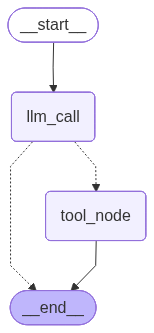

In [28]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [29]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="Add 3 and 4")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================

Add 3 and 4
================================== Ai Message ==================================

[{'id': 'toolu_018YSVobZXy6qeHuzWYSXYBA', 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_018YSVobZXy6qeHuzWYSXYBA)
 Call ID: toolu_018YSVobZXy6qeHuzWYSXYBA
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
